In [ ]:
import sys

assert sys.version_info >= (3, 7)

In [ ]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [ ]:
import tensorflow as tf

assert version.parse(tf.__version__) >= version.parse("2.8.0")

In [ ]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

In [ ]:
import time
import numpy as np
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers


In [ ]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# Scale to [0,1] and float32
X_train = X_train.astype("float32") / 255.0
X_valid = X_valid.astype("float32") / 255.0
X_test  = X_test.astype("float32")  / 255.0

n_classes = 10
input_shape = (28, 28)

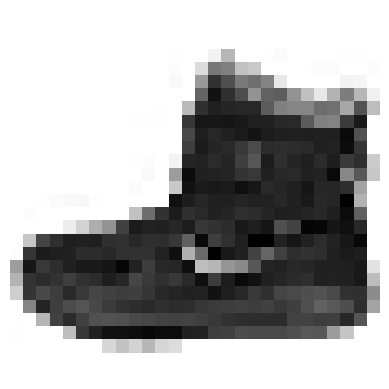

In [ ]:
plt.imshow(X_train[0], cmap="binary")
plt.axis('off')
plt.show()

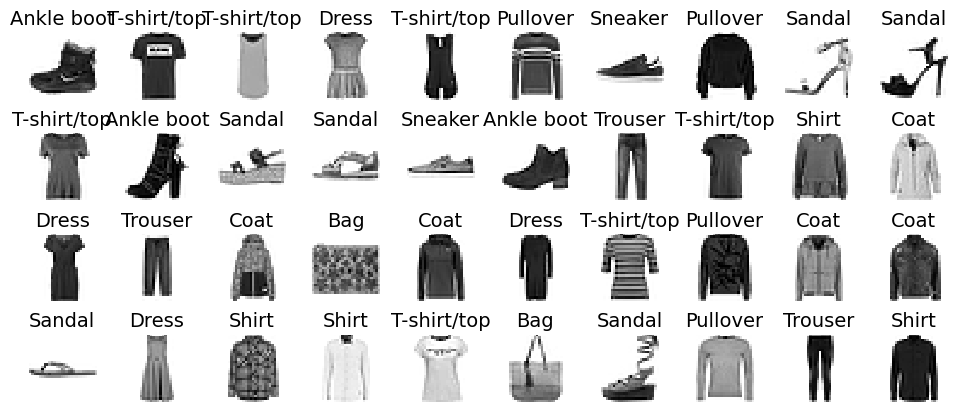

In [ ]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)

plt.show()

In [ ]:
def build_mlp(
    n_hidden_layers=4,
    n_neurons=64,
    activation="relu",
    initializer="glorot_uniform",
    optimizer_name="sgd",
    learning_rate=0.01
):
    model = keras.Sequential()
    model.add(layers.Flatten(input_shape=input_shape))

    for _ in range(n_hidden_layers):
        model.add(
            layers.Dense(
                n_neurons,
                activation=activation,
                kernel_initializer=initializer,
                kernel_regularizer=keras.regularizers.l2(1e-3)
            )
        )

    model.add(layers.Dense(n_classes, activation="softmax"))

    if optimizer_name.lower() == "sgd":
        opt = keras.optimizers.SGD(learning_rate=learning_rate)
    elif optimizer_name.lower() == "adam":
        opt = keras.optimizers.Adam(learning_rate=learning_rate)
    else:
        raise ValueError("optimizer_name must be 'sgd' or 'adam'")

    model.compile(
        loss="sparse_categorical_crossentropy",
        optimizer=opt,
        metrics=["accuracy"],
    )

    return model


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

def run_experiment(
    n_hidden_layers=4,
    n_neurons=64,
    activation="relu",
    initializer="glorot_uniform",
    optimizer_name="sgd",
    learning_rate=0.01,
    batch_size=64,
    epochs=10,
    verbose=0
):
    early_stopping_cb = EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)

    model = build_mlp(
        n_hidden_layers=n_hidden_layers,
        n_neurons=n_neurons,
        activation=activation,
        initializer=initializer,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate,
    )

    start = time.perf_counter()
    history = model.fit(
        X_train,
        y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_data=(X_valid, y_valid),
        callbacks=[early_stopping_cb],
        verbose=verbose,
    )
    train_time = time.perf_counter() - start

    # Take best validation accuracy over epochs
    best_val_acc = max(history.history["val_accuracy"])
    final_train_acc = history.history["accuracy"][-1]

    # Evaluate once on test set
    test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)

    result = {
        "layers": n_hidden_layers,
        "neurons": n_neurons,
        "activation": activation,
        "initializer": initializer,
        "optimizer": optimizer_name,
        "lr": learning_rate,
        "batch_size": batch_size,
        "epochs": epochs,
        "best_val_acc": best_val_acc,
        "final_train_acc": final_train_acc,
        "test_acc": test_acc,
        "train_time_sec": train_time,
    }
    return result, history


In [ ]:
all_results = []
all_histories = []  # if you want to plot learning curves later


In [ ]:
BASE_CONFIG = dict(
    n_hidden_layers=4,
    n_neurons=64,
    activation="relu",
    initializer="glorot_uniform",
    optimizer_name="adam",
    learning_rate=0.001,
    batch_size=32,
    epochs=30,
)


In [ ]:

layers_list = [2,3,4,5]
neurons_list = [16,32, 64, 128, 256,300]

print(f"{'Camadas':<10} | {'Neurônios':<10} | {'Status':<10}")
print("-" * 35)

for layer in layers_list:
  for neuron in neurons_list:
    cfg = BASE_CONFIG.copy()
    cfg["n_hidden_layers"] = layer
    cfg["n_neurons"] = neuron
    result, history = run_experiment(**cfg)
    result["exp_type"] = "grid_search"
    all_results.append(result)
    all_histories.append((cfg, history))
    print(f"{layer:<10} | {neuron:<10} | Concluído")

Camadas    | Neurônios  | Status    
-----------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2          | 16         | Concluído
2          | 32         | Concluído
2          | 64         | Concluído
2          | 128        | Concluído
2          | 256        | Concluído
2          | 300        | Concluído
3          | 16         | Concluído
3          | 32         | Concluído
3          | 64         | Concluído
3          | 128        | Concluído
3          | 256        | Concluído
3          | 300        | Concluído
4          | 16         | Concluído
4          | 32         | Concluído
4          | 64         | Concluído
4          | 128        | Concluído
4          | 256        | Concluído
4          | 300        | Concluído
5          | 16         | Concluído
5          | 32         | Concluído
5          | 64         | Concluído
5          | 128        | Concluído
5          | 256        | Concluído
5          | 300        | Concluído


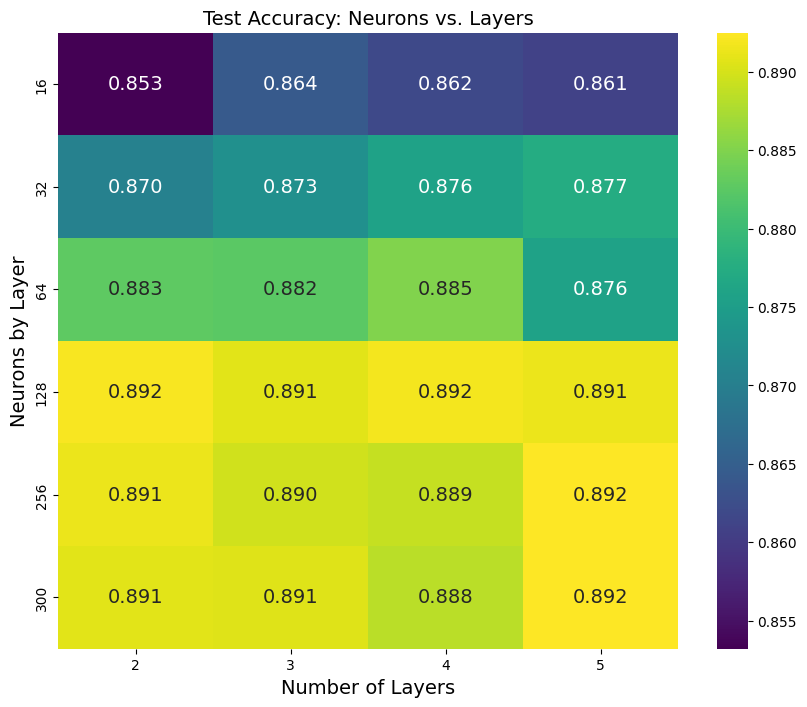

In [ ]:
import seaborn as sns

df = pd.DataFrame(all_results)
pivot_table = df.pivot(index="neurons", columns="layers", values="test_acc")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("Test Accuracy: Neurons vs. Layers")
plt.ylabel("Neurons by Layer")
plt.xlabel("Number of Layers")
plt.show()

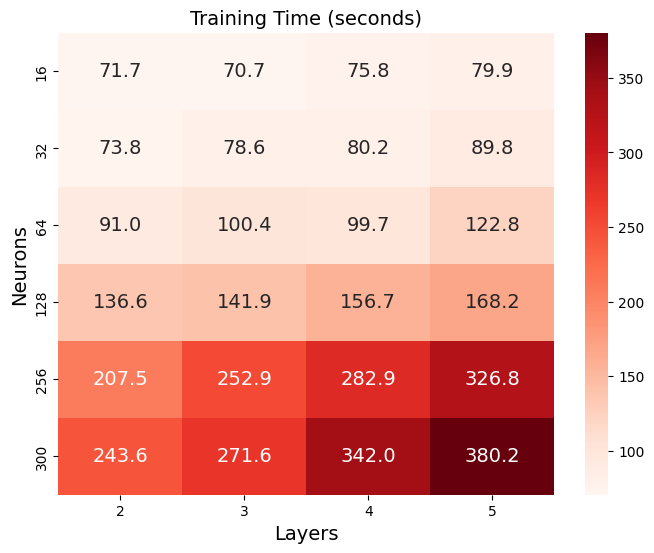

In [ ]:
# Mapa de Calor de TEMPO
pivot_time = df.pivot(index="neurons", columns="layers", values="train_time_sec")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_time, annot=True, fmt=".1f", cmap="Reds") # Reds = quanto mais vermelho, mais lento/pior
plt.title("Training Time (seconds)")
plt.ylabel("Neurons")
plt.xlabel("Layers")
plt.show()

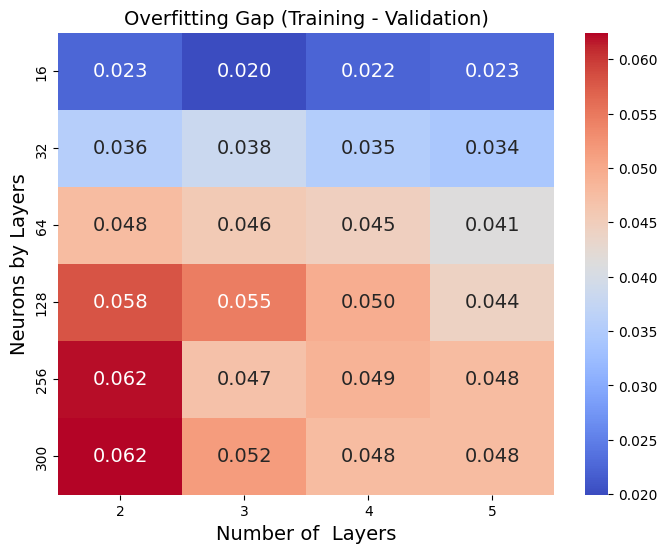

In [ ]:
# Cria coluna de Overfitting
df["overfitting_gap"] = df["final_train_acc"] - df["best_val_acc"]

# Mapa de Calor de OVERFITTING
pivot_gap = df.pivot(index="neurons", columns="layers", values="overfitting_gap")

plt.figure(figsize=(8, 6))
sns.heatmap(pivot_gap, annot=True, fmt=".3f", cmap="coolwarm") # Vermelho = Muito overfitting
plt.title("Overfitting Gap (Training - Validation)")
plt.ylabel("Neurons by Layers")
plt.xlabel("Number of  Layers")
plt.show()

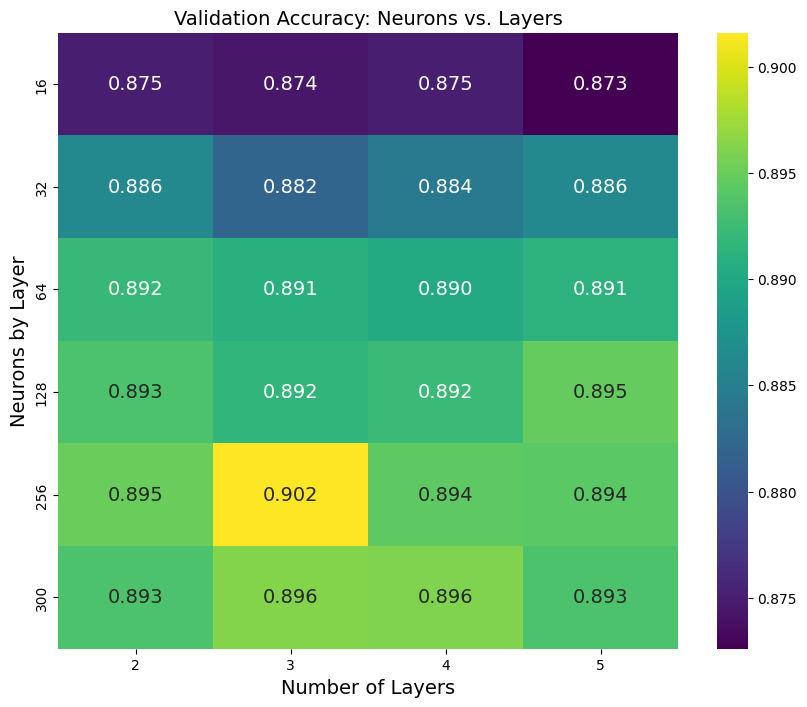

In [ ]:
df = pd.DataFrame(all_results)
pivot_table = df.pivot(index="neurons", columns="layers", values="best_val_acc")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("Validation Accuracy: Neurons vs. Layers")
plt.ylabel("Neurons by Layer")
plt.xlabel("Number of Layers")
plt.show()

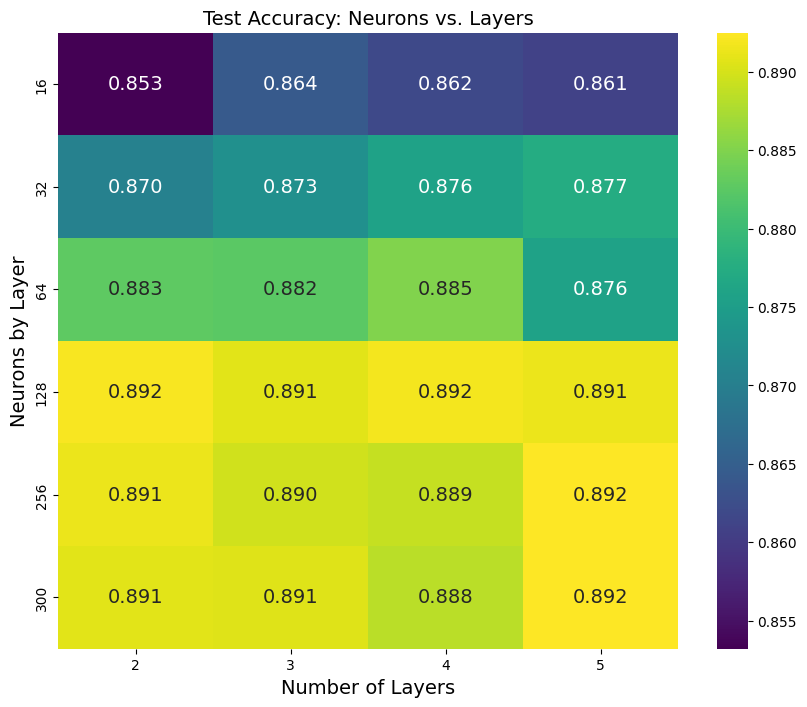

In [ ]:
import seaborn as sns

df = pd.DataFrame(all_results)
pivot_table = df.pivot(index="neurons", columns="layers", values="test_acc")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("Test Accuracy: Neurons vs. Layers")
plt.ylabel("Neurons by Layer")
plt.xlabel("Number of Layers")
plt.show()

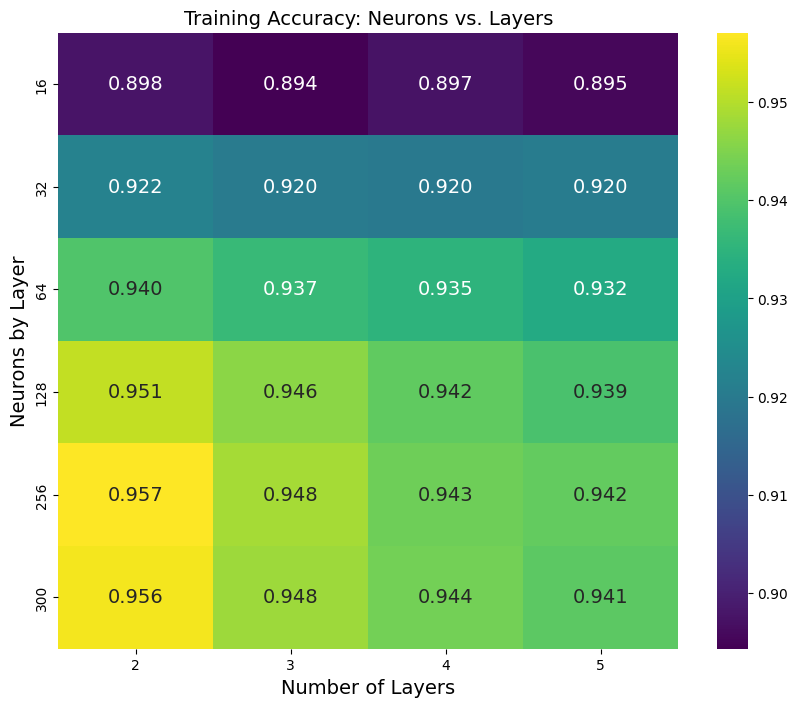

In [ ]:
import seaborn as sns

df = pd.DataFrame(all_results)
pivot_table = df.pivot(index="neurons", columns="layers", values="final_train_acc")

plt.figure(figsize=(10, 8))
sns.heatmap(pivot_table, annot=True, fmt=".3f", cmap="viridis")
plt.title("Training Accuracy: Neurons vs. Layers")
plt.ylabel("Neurons by Layer")
plt.xlabel("Number of Layers")
plt.show()